
# Example Dataset Generator — Tutorial Notebook

This notebook shows how to **generate a synthetic 3D dataset with three channels**
and derived labels/measurements using the provided script. You'll learn how to:

- Install dependencies
- Call the generator from Python (using Click's `Command.main`)
- Inspect the output files (TIFFs and CSV)
- Visualize slices from each channel
- Troubleshoot GPU/headless rendering backends for ModernGL

> **Note:** The generator renders each z-slice via OpenGL/ModernGL. If you're on a headless server,
you may need to specify a backend (e.g. `--backend egl`) and ensure drivers are installed.



## Script location

Update the path below if you placed the script somewhere else.


In [1]:

from pathlib import Path

# Path to the uploaded script in this environment
GENERATOR_SCRIPT_PATH = Path("example-data-generator.py")
GENERATOR_SCRIPT_PATH


PosixPath('example-data-generator.py')


## 1) Install dependencies

Run this once in your environment. On some systems you might install
OpenGL/EGL libraries separately (e.g. `apt install libegl1`, NVIDIA drivers, etc.).


In [2]:

# If running locally, uncomment the following and run once:
# !pip install --upgrade pip
# !pip install moderngl Pillow tifffile scipy pandas scikit-image click



## 2) (Optional) Quick ModernGL smoke test

This checks whether a standalone ModernGL context can be created with your current setup.
If it fails, try specifying `backend="egl"` and ensure EGL/driver libraries are available.


In [3]:
import moderngl
ctx = moderngl.create_standalone_context()
print("ModernGL context OK:", ctx)

ModernGL context OK: <moderngl.Context object at 0x75bc780b9010>



## 3) Import the generator

The script exposes a Click command named `generate_data`. We import it from the file path
and call it via `command.main([...])` with `standalone_mode=False` so exceptions surface
in the notebook.


In [4]:

import importlib.util, sys

spec = importlib.util.spec_from_file_location("dataset_gen", str(GENERATOR_SCRIPT_PATH))
mod = importlib.util.module_from_spec(spec)
sys.modules["dataset_gen"] = mod
spec.loader.exec_module(mod)

# The Click command object
generate_cmd = mod.generate_data
generate_cmd


<Command generate-data>


## 4) Choose output directory and parameters and generate dataset

- `size` controls the width/height/depth of the 3D volume (voxels).  
- `backend` can be omitted (ModernGL will pick a default) or set to `"egl"` in headless setups.

**Tip:** Start with a small size (e.g. `64` or `96`) to test quickly, then scale up.


In [5]:
from pathlib import Path
OUT_DIR = Path("./synthetic_demo_out").resolve()
SIZE = 256   # try 64 or 96 for a quick run; larger sizes take longer
BACKEND = None  # or "egl" if running headless with EGL available

generate_cmd.main([str(OUT_DIR), "--size", str(SIZE), "--backend", BACKEND], standalone_mode=False)

Exporting to /media/data/Development/hi/repos/workshops/3d-data-visualization/notebooks/synthetic_demo_out..


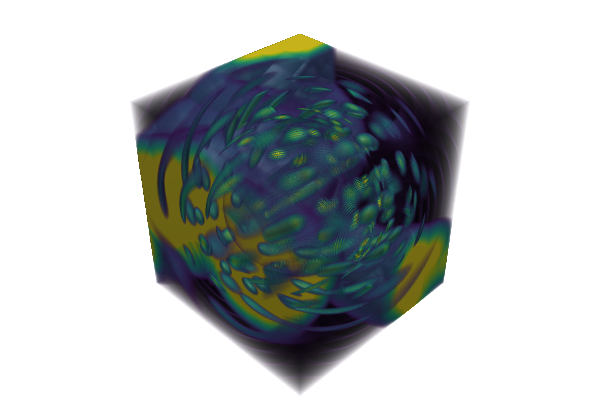

In [6]:
import numpy as np
import tifffile as tiff
import pyvista as pv
from pathlib import Path

OUT_DIR = Path("../example_data") / "size_256" 

plotter = pv.Plotter(window_size=(600, 400))
plotter.add_volume(pv.wrap(tiff.imread(str(OUT_DIR / "raw_channel1.tif"))), shade=True)
plotter.add_volume(pv.wrap(tiff.imread(str(OUT_DIR / "raw_channel2.tif"))), shade=True)
plotter.add_volume(pv.wrap(tiff.imread(str(OUT_DIR / "raw_channel3.tif"))), shade=True)
plotter.remove_scalar_bar()
plotter.show(screenshot=Path("../example_data") / "size_256" / 'pyvista_volume_preview.png', jupyter_backend="static")



## 6) Inspect the outputs

The generator writes the following to `OUT_DIR`:

- `raw_channel1.tif`, `raw_channel2.tif`, `raw_channel3.tif` — normalized synthetic 3D volumes  
- `segmentation_channel1.tif`, `segmentation_channel2.tif` — simple binary segmentations  
- `labelmap_channel3.tif` — connected-component label map (from channel 3)  
- `analysis_data_channel3.csv` — region properties (area, axes lengths, elongation) computed from the label map


In [7]:

from pathlib import Path
for p in sorted(OUT_DIR.glob("*")):
    print(p.name, p.stat().st_size, "bytes")


analysis_data_channel3.csv 25469 bytes
labelmap_channel3.tif 497620 bytes
pyvista_volume_preview.png 137351 bytes
raw_channel1.tif 1872324 bytes
raw_channel2.tif 4576324 bytes
raw_channel3.tif 2060356 bytes
segmentation_channel1.tif 113412 bytes
segmentation_channel2.tif 192180 bytes


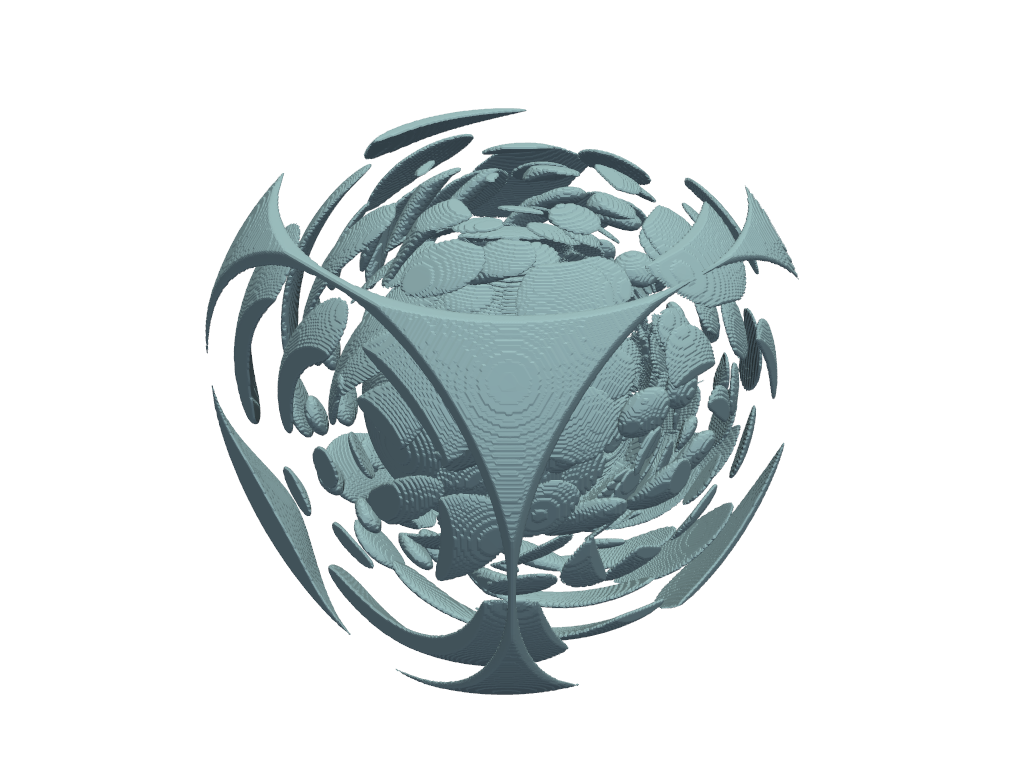

In [8]:
vol = tiff.imread(Path("../example_data") / "size_256" / "raw_channel3.tif")
vol.shape, vol.dtype, float(vol.min()), float(vol.max())

# Wrap the numpy volume into a UniformGrid
grid = pv.ImageData()
grid.dimensions = vol.shape[::-1]  # X, Y, Z
grid.point_data['values'] = vol.ravel(order='F')

# 2.1 Extract isosurface
level = 0.5
# If your PyVista supports it, you can use method='flying_edges' (VTK's vtkFlyingEdges3D)
# surf = grid.contour(isosurfaces=[level], scalars='values', method='flying_edges')
surf = grid.contour(isosurfaces=[level], scalars='values')

# 2.2 Optional smoothing
surf_sm = surf.smooth(n_iter=30, relaxation_factor=0.01)

# 2.3 Optional decimation
surf_dec = surf_sm.decimate(target_reduction=0.5, inplace=False)

# 2.4 Exports
surf_dec.save(Path("../example_data") / "size_256" / 'mesh_channel3.stl')
surf_dec.save(Path("../example_data") / "size_256" / 'mesh_channel3.ply')

# 2.5 Static PNG preview (off-screen)
pl = pv.Plotter(off_screen=True)
pl.add_mesh(surf_dec)
pl.set_background('white')
pl.show(screenshot=Path("../example_data") / "size_256" / 'pyvista_mesh_preview.png',auto_close=True, jupyter_backend="static")